# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np

expressao_genica = np.random.normal(loc=0, scale=1, size=1000)

upregulated = expressao_genica[expressao_genica > 0]
downregulated = expressao_genica[expressao_genica < 0]

print("Valores de expressão gênica:")
print(expressao_genica)

print("Quantidade de genes upregulated:", len(upregulated))
print("Quantidade de genes downregulated:", len(downregulated))

print("Genes upregulated:")
print(upregulated)

print("Genes downregulated:")
print(downregulated)

Valores de expressão gênica:
[-4.44208105e-01 -1.67407615e-01  5.68570439e-01  6.57745371e-01
  1.17301467e-01  8.85162319e-01  8.86221699e-01  1.69221939e+00
 -8.92995862e-01  4.63471553e-01  1.90154117e-01 -3.94375326e-01
 -2.85349980e-01  6.19771124e-01  1.10171799e+00 -2.55494716e-01
  4.30537280e-01 -4.90560147e-01 -1.54702280e-01 -9.27994320e-01
  1.23163548e+00  4.94575190e-02 -1.24192063e+00 -9.27414830e-01
  2.90633332e+00 -1.18622721e+00  2.08715367e+00 -1.10783327e+00
  4.29232971e-01  1.70346638e+00  1.54495412e-01 -2.36212029e-01
  5.29048704e-01  7.97513402e-01 -6.96107499e-01  1.09839136e+00
  1.22224069e+00 -4.91848103e-01  9.72857902e-01  6.75538348e-01
  1.34323144e-01 -1.57409567e-01  4.24844626e-01  1.28030299e+00
  1.13715708e+00  5.94399265e-01 -2.88222671e-02 -1.08922845e+00
  5.82864928e-01  6.71780997e-01 -1.38477835e+00  3.60109912e-02
 -1.33554135e+00  9.64683444e-01  1.71080471e-01 -6.39036833e-01
  6.29927643e-03  2.76255674e-01  9.60580006e-01 -1.02043150e

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [2]:
import numpy as np
import pandas as pd

expressao_genica = np.random.normal(loc=0, scale=1, size=1000)

status_expressao = np.where(
    expressao_genica > 0,
    "upregulated",
    "downregulated"
)

genes_diferenciais = np.random.randint(1, 1000, size=1000)

status_pacientes = np.where(
    genes_diferenciais > 500,
    "upregulated",
    "downregulated"
)

df = pd.DataFrame({
    "expressao_genica": expressao_genica,
    "status_expressao": status_expressao,
    "genes_diferenciais": genes_diferenciais,
    "status_pacientes": status_pacientes
})

print(df)

     expressao_genica status_expressao  genes_diferenciais status_pacientes
0            1.010673      upregulated                 589      upregulated
1           -0.168447    downregulated                 714      upregulated
2            0.548683      upregulated                 997      upregulated
3           -0.429175    downregulated                 483    downregulated
4            0.620590      upregulated                 407    downregulated
..                ...              ...                 ...              ...
995          1.413561      upregulated                 884      upregulated
996         -0.283606    downregulated                 480    downregulated
997          1.173522      upregulated                 112    downregulated
998          0.446927      upregulated                 335    downregulated
999         -0.238337    downregulated                 686      upregulated

[1000 rows x 4 columns]


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: 

In [3]:
import pandas as pd

df["grupo_expressao"] = pd.cut(
    df["expressao_genica"],
    bins=6,
    labels=[
        "muito_downregulated",
        "downregulated",
        "levemente_downregulated",
        "levemente_upregulated",
        "upregulated",
        "muito_upregulated"
    ]
)

df["grupo_genes_diferenciais"] = pd.cut(
    df["genes_diferenciais"],
    bins=6,
    labels=[
        "muito_baixo",
        "baixo",
        "moderado_baixo",
        "moderado_alto",
        "alto",
        "muito_alto"
    ]
)

print(df)

     expressao_genica status_expressao  genes_diferenciais status_pacientes  \
0            1.010673      upregulated                 589      upregulated   
1           -0.168447    downregulated                 714      upregulated   
2            0.548683      upregulated                 997      upregulated   
3           -0.429175    downregulated                 483    downregulated   
4            0.620590      upregulated                 407    downregulated   
..                ...              ...                 ...              ...   
995          1.413561      upregulated                 884      upregulated   
996         -0.283606    downregulated                 480    downregulated   
997          1.173522      upregulated                 112    downregulated   
998          0.446927      upregulated                 335    downregulated   
999         -0.238337    downregulated                 686      upregulated   

             grupo_expressao grupo_genes_diferencia

In [ ]:
O critério usado foi dividir os valores numéricos em 6 faixas de mesma largura.

Para expressao_genica, valores menores representam genes mais downregulated, enquanto valores maiores representam genes mais upregulated.

Para genes_diferenciais, valores menores indicam menor número de genes diferencialmente expressos, enquanto valores maiores indicam maior número desses genes.

## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [4]:
import pandas as pd

def tabela_frequencia(serie):
    frequencia = serie.value_counts().sort_index()

    df_freq = pd.DataFrame({
        "valor": frequencia.index,
        "frequencia": frequencia.values
    })

    return df_freq


freq_expressao = tabela_frequencia(df["grupo_expressao"])
freq_genes_diferenciais = tabela_frequencia(df["grupo_genes_diferenciais"])

print(freq_expressao)
print(freq_genes_diferenciais)

                     valor  frequencia
0      muito_downregulated          10
1            downregulated         134
2  levemente_downregulated         400
3    levemente_upregulated         350
4              upregulated          98
5        muito_upregulated           8
            valor  frequencia
0     muito_baixo         169
1           baixo         152
2  moderado_baixo         161
3   moderado_alto         158
4            alto         187
5      muito_alto         173


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

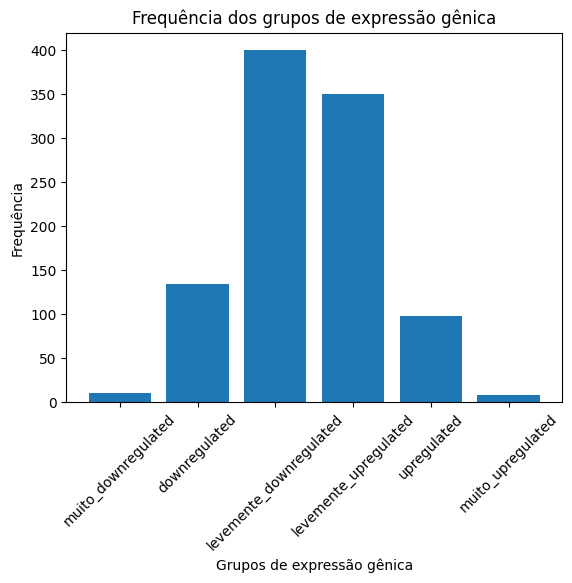

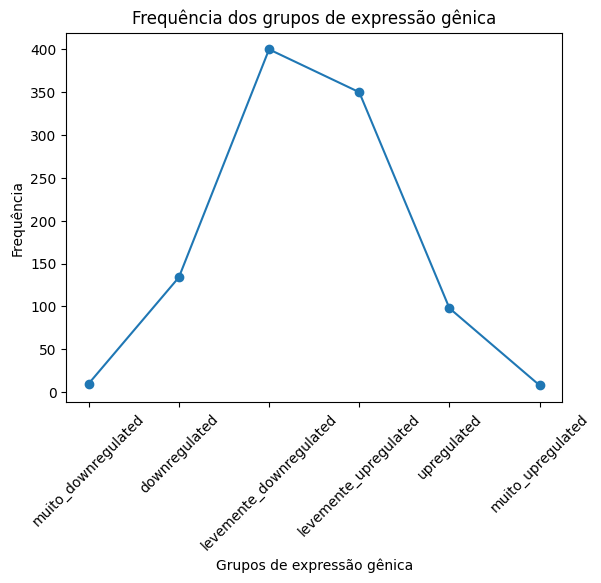

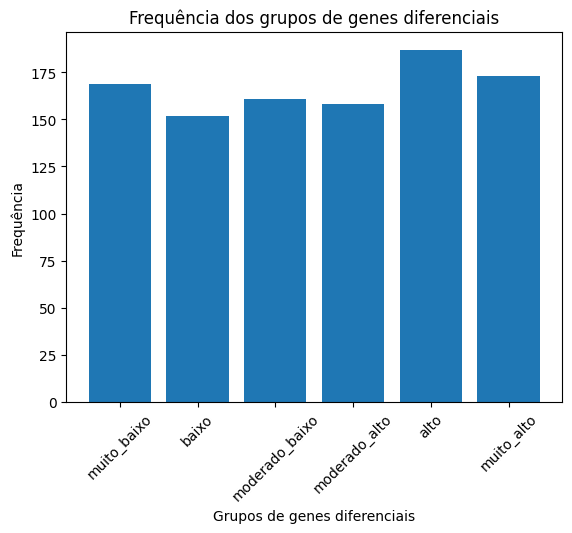

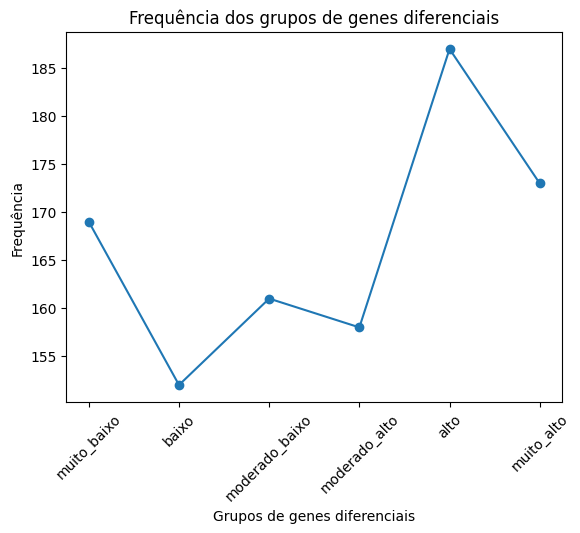

In [5]:
import matplotlib.pyplot as plt

plt.bar(freq_expressao["valor"], freq_expressao["frequencia"])
plt.xlabel("Grupos de expressão gênica")
plt.ylabel("Frequência")
plt.title("Frequência dos grupos de expressão gênica")
plt.xticks(rotation=45)
plt.show()

plt.plot(freq_expressao["valor"], freq_expressao["frequencia"], marker="o")
plt.xlabel("Grupos de expressão gênica")
plt.ylabel("Frequência")
plt.title("Frequência dos grupos de expressão gênica")
plt.xticks(rotation=45)
plt.show()

plt.bar(freq_genes_diferenciais["valor"], freq_genes_diferenciais["frequencia"])
plt.xlabel("Grupos de genes diferenciais")
plt.ylabel("Frequência")
plt.title("Frequência dos grupos de genes diferenciais")
plt.xticks(rotation=45)
plt.show()

plt.plot(freq_genes_diferenciais["valor"], freq_genes_diferenciais["frequencia"], marker="o")
plt.xlabel("Grupos de genes diferenciais")
plt.ylabel("Frequência")
plt.title("Frequência dos grupos de genes diferenciais")
plt.xticks(rotation=45)
plt.show()

### Expressão

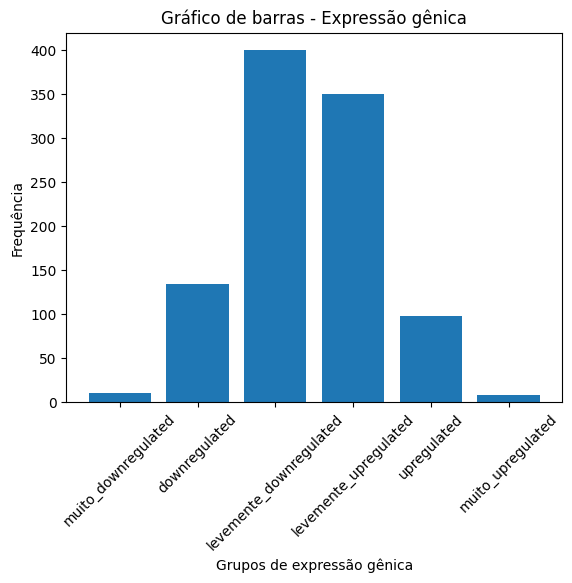

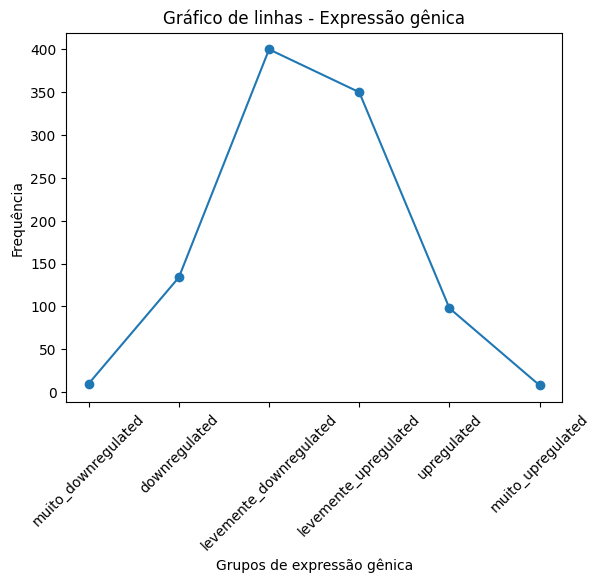

In [6]:
import matplotlib.pyplot as plt

plt.bar(freq_expressao["valor"], freq_expressao["frequencia"])
plt.xlabel("Grupos de expressão gênica")
plt.ylabel("Frequência")
plt.title("Gráfico de barras - Expressão gênica")
plt.xticks(rotation=45)
plt.show()

plt.plot(freq_expressao["valor"], freq_expressao["frequencia"], marker="o")
plt.xlabel("Grupos de expressão gênica")
plt.ylabel("Frequência")
plt.title("Gráfico de linhas - Expressão gênica")
plt.xticks(rotation=45)
plt.show()

### Número

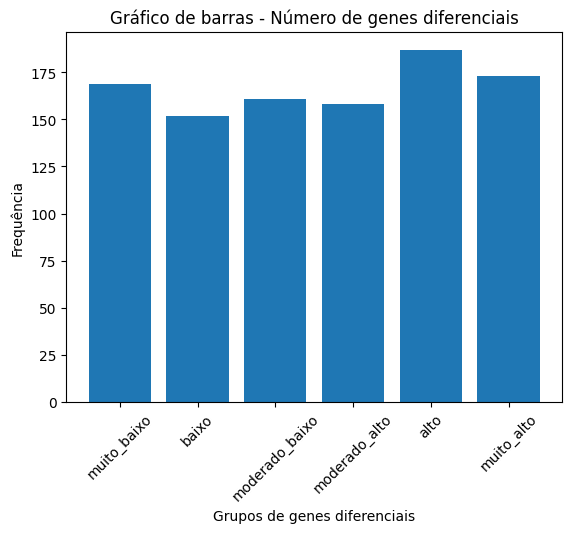

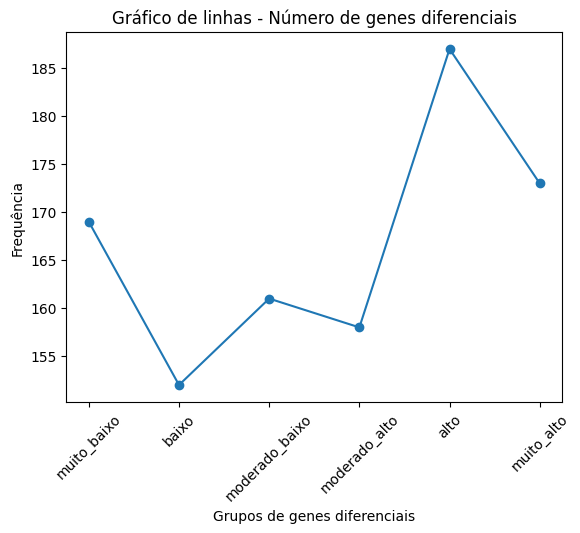

In [7]:
import matplotlib.pyplot as plt

plt.bar(freq_genes_diferenciais["valor"], freq_genes_diferenciais["frequencia"])
plt.xlabel("Grupos de genes diferenciais")
plt.ylabel("Frequência")
plt.title("Gráfico de barras - Número de genes diferenciais")
plt.xticks(rotation=45)
plt.show()

plt.plot(freq_genes_diferenciais["valor"], freq_genes_diferenciais["frequencia"], marker="o")
plt.xlabel("Grupos de genes diferenciais")
plt.ylabel("Frequência")
plt.title("Gráfico de linhas - Número de genes diferenciais")
plt.xticks(rotation=45)
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

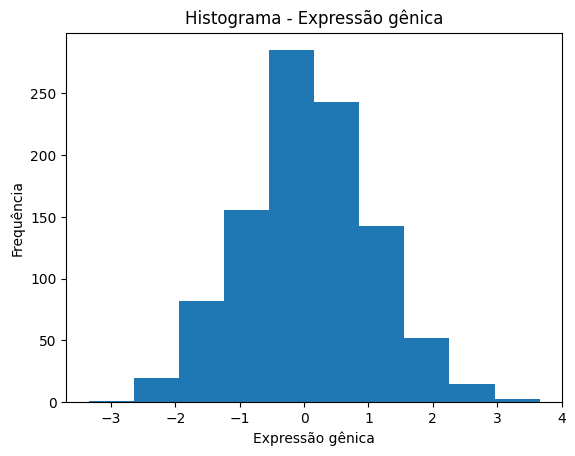

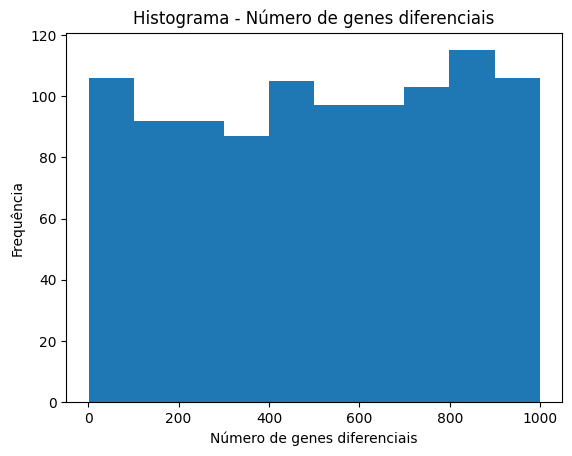

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["expressao_genica"])
plt.xlabel("Expressão gênica")
plt.ylabel("Frequência")
plt.title("Histograma - Expressão gênica")
plt.show()

plt.hist(df["genes_diferenciais"])
plt.xlabel("Número de genes diferenciais")
plt.ylabel("Frequência")
plt.title("Histograma - Número de genes diferenciais")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

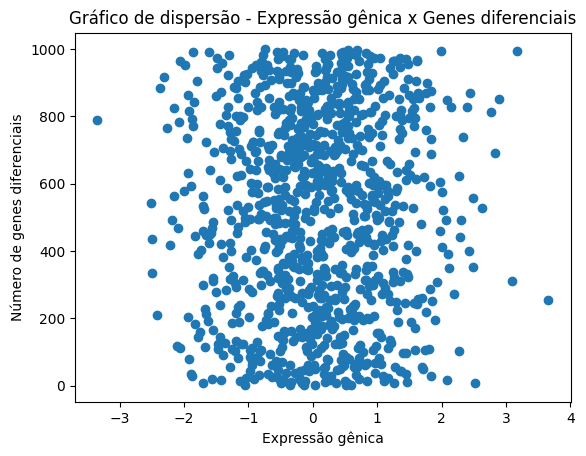

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df["expressao_genica"], df["genes_diferenciais"])
plt.xlabel("Expressão gênica")
plt.ylabel("Número de genes diferenciais")
plt.title("Gráfico de dispersão - Expressão gênica x Genes diferenciais")
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

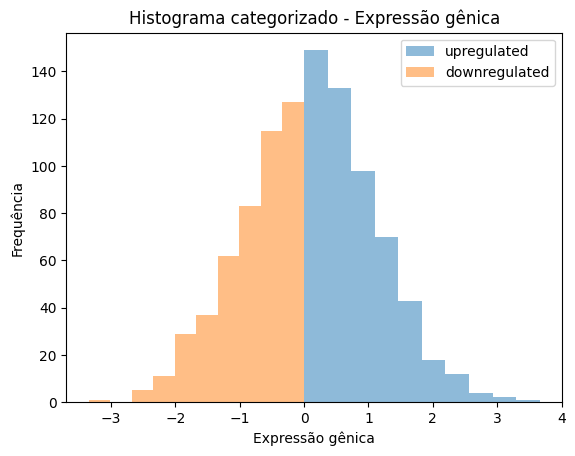

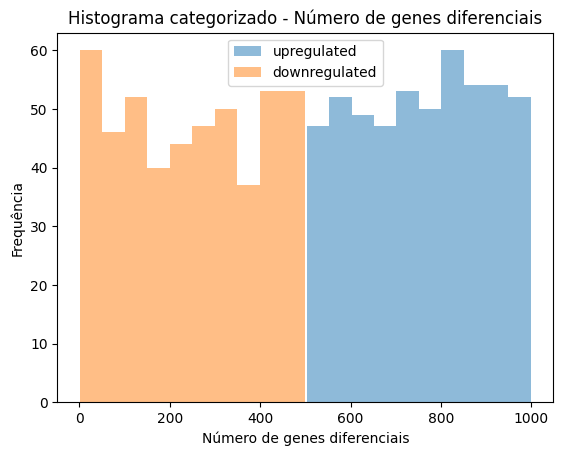

In [10]:
import matplotlib.pyplot as plt

plt.hist(
    df[df["status_expressao"] == "upregulated"]["expressao_genica"],
    alpha=0.5,
    label="upregulated"
)

plt.hist(
    df[df["status_expressao"] == "downregulated"]["expressao_genica"],
    alpha=0.5,
    label="downregulated"
)

plt.xlabel("Expressão gênica")
plt.ylabel("Frequência")
plt.title("Histograma categorizado - Expressão gênica")
plt.legend()
plt.show()


plt.hist(
    df[df["status_pacientes"] == "upregulated"]["genes_diferenciais"],
    alpha=0.5,
    label="upregulated"
)

plt.hist(
    df[df["status_pacientes"] == "downregulated"]["genes_diferenciais"],
    alpha=0.5,
    label="downregulated"
)

plt.xlabel("Número de genes diferenciais")
plt.ylabel("Frequência")
plt.title("Histograma categorizado - Número de genes diferenciais")
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

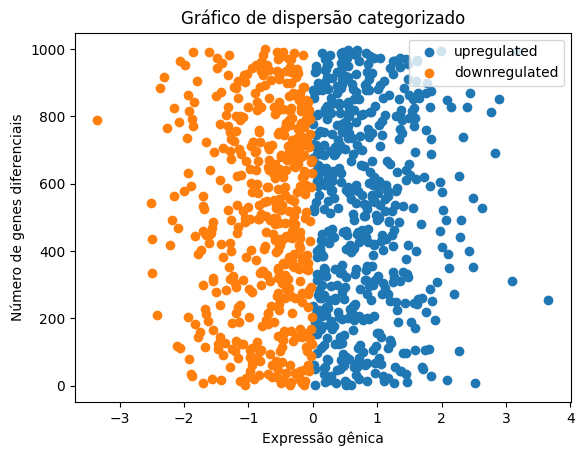

In [11]:
import matplotlib.pyplot as plt

for categoria in df["status_expressao"].unique():
    dados = df[df["status_expressao"] == categoria]

    plt.scatter(
        dados["expressao_genica"],
        dados["genes_diferenciais"],
        label=categoria
    )

plt.xlabel("Expressão gênica")
plt.ylabel("Número de genes diferenciais")
plt.title("Gráfico de dispersão categorizado")
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

In [ ]:
| Variável               |   Valor  |
| :--------------------- | :------: |
| # de células positivas | Discreta |
| % de células positivas | Contínua |
| Faixa de pH            |  Ordinal |
| Valor de pH            | Contínua |
| mol/L                  | Contínua |
| UFC                    | Discreta |
| D.O.                   | Contínua |
| Grupo Sanguíneo        |  Nominal |
| Sorologia              |  Nominal |
